# Lab 6 — Solving hard problems the slow way

**Maths for Post-Quantum Cryptography**, Chapter 6: *Hard Problems*

---

Four pieces. Part A implements SVP and CVP exactly, by brute force, on the
running example. Part B watches that brute force explode combinatorially
with dimension — the concrete reason Chapter 8 abandons exactness for a
tunable approximation. Part C makes Derivation 6.1's uniqueness radius
concrete: decode successfully under $\lambda_1/2$, and reproduce the exact
tie at $\lambda_1/2$. Part D builds toy GapSVP instances and is explicit
that solving them trivially at $n=2$ demonstrates nothing about the
hardness Chapter 8 actually measures.

**Part A — SVP and CVP by brute force.** Exhaustive search over integer
coefficients; reproduce Figure 6.1 exactly.

**Part B — the cost of being exact.** Benchmark brute-force SVP across
dimensions 2 through 8.

**Part C — the uniqueness radius.** Reproduce Figure 6.2's two panels
numerically.

**Part D — toy GapSVP instances.** $\mathbb{Z}^n$ and $q\mathbb{Z}^n$ as
YES/NO instances, distinguished trivially at toy dimension.

### Requirements

```
python >= 3.9
numpy
matplotlib
```

Nothing else — every algorithm here is written directly from the chapter's
definitions, in plain Python, with no lattice-reduction library standing in
for brute force (that would defeat the point of Part B entirely).

### How to use this notebook

Run it top to bottom once. Worked solutions for the pencil-and-paper
exercises (6.1-6.7, 6.11) are in Appendix C of the book.

Every section ends with `assert` statements, and the final cell is a single
`_selftest()` that repeats all of them. CI runs this notebook on every
commit; if an assertion fires on your machine, that is a bug in the lab, not
in your understanding — please open an issue.

In [1]:
from __future__ import annotations

import itertools
import random
import time
from math import sqrt

import numpy as np
import matplotlib.pyplot as plt

# Same print-safe, black-and-white styling as Labs 1-5.
plt.rcParams.update({
    "figure.figsize": (7.5, 3.4),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": ":",
    "axes.prop_cycle": plt.cycler(color=["0.15", "0.45", "0.65"]),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 9,
})

random.seed(0)
np.random.seed(0)
print(f"numpy {np.__version__}")

numpy 2.4.4


---

## Part A — SVP and CVP by brute force

`svp_bruteforce` and `cvp_bruteforce` both search every integer
coefficient vector in a bounded range — exactly Definitions 6.1 and 6.2,
made literal. Reproduces Figure 6.1's claim: the closest lattice point to
$t=(2,2)$ is $(1,3)$, at distance $\sqrt2$.

In [2]:
def svp_bruteforce(B, coeff_range=6):
    """Exact SVP: shortest nonzero vector, by exhaustive search."""
    n = B.shape[0]
    best = None
    for coeffs in itertools.product(range(-coeff_range, coeff_range + 1), repeat=n):
        if all(c == 0 for c in coeffs):
            continue
        v = np.array(coeffs) @ B
        norm = np.linalg.norm(v)
        if best is None or norm < best:
            best = norm
    return best


def cvp_bruteforce(B, t, coeff_range=6):
    """Exact CVP: closest lattice point to t, by exhaustive search."""
    n = B.shape[0]
    best_dist, best_v, best_c = None, None, None
    for coeffs in itertools.product(range(-coeff_range, coeff_range + 1), repeat=n):
        v = np.array(coeffs) @ B
        d = np.linalg.norm(v - t)
        if best_dist is None or d < best_dist:
            best_dist, best_v, best_c = d, v, coeffs
    return best_v, best_c, best_dist


# The book's running example: b1=(4,2), b2=(1,3).
B = np.array([[4, 2], [1, 3]])

lam1 = svp_bruteforce(B)
print("lambda_1 =", lam1)
assert abs(lam1 - sqrt(10)) < 1e-9

t = np.array([2.0, 2.0])
v, c, d = cvp_bruteforce(B, t)
print("closest lattice point to (2,2):", v, "coeffs", c, "distance", d)
assert np.allclose(v, [1, 3])
assert abs(d - sqrt(2)) < 1e-9

# The two runner-up candidates from Exercise 6.1.
for v_check in ([0, 0], [5, 5]):
    d_check = np.linalg.norm(np.array(v_check) - t)
    print(f"  distance from {v_check} to t: {d_check:.4f} (vs {d:.4f} for (1,3))")
    assert d_check > d

lambda_1 = 3.1622776601683795
closest lattice point to (2,2): [1 3] coeffs (0, 1) distance 1.4142135623730951
  distance from [0, 0] to t: 2.8284 (vs 1.4142 for (1,3))
  distance from [5, 5] to t: 4.2426 (vs 1.4142 for (1,3))


---

## Part B — the cost of being exact

Brute-force SVP's running time, as a function of dimension $n$, with a
fixed coefficient search range. The combinatorial growth is the entire
point: this is exactly why Chapter 8 uses LLL/BKZ (polynomial time,
adjustable approximation) instead of ever trying to be exact past a
handful of dimensions.

n=2:           49 coefficient vectors,    0.001s
n=3:          343 coefficient vectors,    0.002s
n=4:        2,401 coefficient vectors,    0.010s
n=5:       16,807 coefficient vectors,    0.071s


n=6:      117,649 coefficient vectors,    0.518s


n=7:      823,543 coefficient vectors,    3.575s


n=8:    5,764,801 coefficient vectors,   25.565s


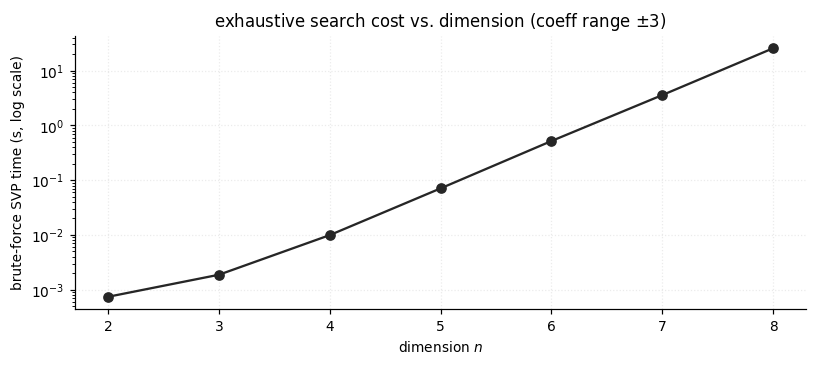

n=2 to n=8: 34324x slower (search space grew 117,649x)


In [3]:
def random_basis(n, low=-4, high=4, max_tries=200):
    for _ in range(max_tries):
        Bt = np.random.randint(low, high + 1, size=(n, n))
        if abs(round(np.linalg.det(Bt))) > 0:
            return Bt
    raise RuntimeError("could not find a full-rank basis")


dims = [2, 3, 4, 5, 6, 7, 8]
times = []
combos = []
COEFF_RANGE = 3
for n in dims:
    Bn = random_basis(n)
    t0 = time.time()
    svp_bruteforce(Bn, coeff_range=COEFF_RANGE)
    elapsed = time.time() - t0
    times.append(elapsed)
    combos.append((2 * COEFF_RANGE + 1) ** n)
    print(f"n={n}: {combos[-1]:>12,} coefficient vectors, {elapsed:8.3f}s")

fig, ax = plt.subplots()
ax.semilogy(dims, [max(t_, 1e-4) for t_ in times], marker="o", color="0.15")
ax.set_xlabel("dimension $n$")
ax.set_ylabel("brute-force SVP time (s, log scale)")
ax.set_title(f"exhaustive search cost vs. dimension (coeff range $\\pm${COEFF_RANGE})")
plt.tight_layout()
plt.show()

# The growth is combinatorial: going from n to n+2 should cost noticeably
# more than a constant-factor increase once search space dominates.
assert times[-1] > times[0]
print(f"n={dims[0]} to n={dims[-1]}: {times[-1] / max(times[0], 1e-6):.0f}x slower "
      f"(search space grew {combos[-1] / combos[0]:,.0f}x)")

---

## Part C — the uniqueness radius

Derivation 6.1: BDD has a unique answer whenever $\alpha < 1/2$, and the
bound is tight — reproduce both halves of that claim on the running
example, then confirm it holds generally.

In [4]:
lam1 = sqrt(10)

# Panel (a): unique decoding, noise strictly under lambda_1/2.
v0 = np.array([4.0, 2.0])
e = np.array([0.5, -0.3])
print("norm(e) =", np.linalg.norm(e), " lambda_1/2 =", lam1 / 2)
assert np.linalg.norm(e) < lam1 / 2

t_unique = v0 + e
v_rec, c_rec, d_rec = cvp_bruteforce(B, t_unique)
print("unique-decoding target:", t_unique, "-> recovered", v_rec, " matches v0?", np.allclose(v_rec, v0))
assert np.allclose(v_rec, v0)

# Panel (b): the exact tie at lambda_1/2 -- midpoint of 0 and the shortest vector.
t_tied = np.array([-1.5, 0.5])
n = B.shape[0]
dists = []
for coeffs in itertools.product(range(-5, 6), repeat=n):
    v = np.array(coeffs) @ B
    dists.append((np.linalg.norm(v - t_tied), tuple(v.tolist())))
dists.sort(key=lambda x: x[0])
print("closest five lattice points to the tied target:")
for dd, vv in dists[:5]:
    print(f"  {vv}: distance {dd:.6f}")

closest_dist = dists[0][0]
tied = [v for dd, v in dists if abs(dd - closest_dist) < 1e-9]
print("points tied for closest:", tied)
assert len(tied) == 2
assert set(tied) == {(0, 0), (-3, 1)}
assert abs(closest_dist - lam1 / 2) < 1e-9
# Exercise 6.3: confirm the next-nearest points are strictly farther.
assert dists[2][0] > closest_dist + 1e-6

# General check: random small noise under lambda_1/2 always decodes uniquely
# back to the point it was added to.
checked = 0
for _ in range(300):
    coeffs = np.random.randint(-4, 5, size=2)
    v_true = coeffs @ B
    # random noise direction, magnitude strictly under lambda_1/2
    theta = np.random.uniform(0, 2 * np.pi)
    r = np.random.uniform(0, 0.499) * lam1
    noise = r * np.array([np.cos(theta), np.sin(theta)])
    target = v_true + noise
    v_found, _, _ = cvp_bruteforce(B, target, coeff_range=6)
    assert np.allclose(v_found, v_true)
    checked += 1
print(f"unique decoding confirmed on {checked} random points with noise < lambda_1/2")

norm(e) = 0.58309518948453  lambda_1/2 = 1.5811388300841898
unique-decoding target: [4.5 1.7] -> recovered [4 2]  matches v0? True
closest five lattice points to the tied target:
  (-3, 1): distance 1.581139
  (0, 0): distance 1.581139
  (-4, -2): distance 3.535534
  (-2, 4): distance 3.535534
  (-1, -3): distance 3.535534
points tied for closest: [(-3, 1), (0, 0)]


unique decoding confirmed on 300 random points with noise < lambda_1/2


---

## Part D — toy GapSVP instances

$(\mathbb{Z}^n, 1)$ is a YES instance of $\mathrm{GapSVP}_\gamma$ for every
$\gamma$; $(q\mathbb{Z}^n, 1)$ is a NO instance whenever $\gamma < q$.
Brute-force SVP distinguishes them trivially at small $n$ — which is the
point being made explicit, not hidden: this triviality is an artefact of
diagonal, contrived lattices at toy dimension, and says nothing about the
hardness of a random instance at cryptographic size (Chapter 8).

In [5]:
def gap_svp_decide(B, d, gamma):
    """Brute-force GapSVP_gamma decision: True = YES (lambda_1 <= d),
    False = NO (lambda_1 > gamma*d). Undefined (per the promise) in between,
    but brute force just reports the true lambda_1 regardless."""
    lam1 = svp_bruteforce(B, coeff_range=max(2, int(d) + 2))
    if lam1 <= d:
        return True, lam1
    elif lam1 > gamma * d:
        return False, lam1
    else:
        return None, lam1  # inside the excluded gap


results = []
for n, q, gamma in [(2, 5, 3), (3, 7, 4), (4, 6, 3)]:
    Z_n = np.eye(n, dtype=int)
    qZ_n = q * np.eye(n, dtype=int)
    yes_decision, yes_lam1 = gap_svp_decide(Z_n, d=1, gamma=gamma)
    no_decision, no_lam1 = gap_svp_decide(qZ_n, d=1, gamma=gamma)
    print(f"n={n}, q={q}, gamma={gamma}: Z^n lambda_1={yes_lam1} -> "
          f"{'YES' if yes_decision else yes_decision}; "
          f"q*Z^n lambda_1={no_lam1} -> {'NO' if no_decision is False else no_decision}")
    assert yes_decision is True
    assert no_decision is False
    results.append((n, q, gamma))

print(f"GapSVP toy instances correctly distinguished for {len(results)} (n,q,gamma) triples")

# Timing check (Exercise 6.10): largest n where brute-force SVP on Z^n
# still completes in under one second, at a generous coefficient range.
for n in range(2, 9):
    t0 = time.time()
    svp_bruteforce(np.eye(n, dtype=int), coeff_range=2)
    elapsed = time.time() - t0
    print(f"n={n}: {elapsed:.4f}s")
    if elapsed > 1.0:
        print(f"  -> exceeded 1s at n={n}")
        break

n=2, q=5, gamma=3: Z^n lambda_1=1.0 -> YES; q*Z^n lambda_1=5.0 -> NO
n=3, q=7, gamma=4: Z^n lambda_1=1.0 -> YES; q*Z^n lambda_1=7.0 -> NO
n=4, q=6, gamma=3: Z^n lambda_1=1.0 -> YES; q*Z^n lambda_1=6.0 -> NO
GapSVP toy instances correctly distinguished for 3 (n,q,gamma) triples
n=2: 0.0001s
n=3: 0.0005s
n=4: 0.0029s
n=5: 0.0135s
n=6: 0.0683s


n=7: 0.3531s


n=8: 1.7679s
  -> exceeded 1s at n=8


---

## What to take away

Every part of this lab was exact, and every part was small. That is not a
limitation of the code — it is the entire content of Chapter 6's argument.
Exact SVP and CVP are well-defined, brute force always finds the right
answer, and none of it scales past a handful of dimensions. Cryptography
needs hardness at $n$ in the hundreds, where brute force is not a fallback
of last resort but simply impossible, and where the honest question stops
being "can I solve this exactly" and becomes "how good an approximation can
the best published algorithm reach, and at what cost" — Chapter 8's
question, not this lab's.

In [6]:
# --------------------------------------------------------------------------
# CI smoke test. Runs on every commit; keeps this notebook honest against
# library updates. If this cell fails, the lab is broken -- please open an issue.
# --------------------------------------------------------------------------
def _selftest():
    B_ = np.array([[4, 2], [1, 3]])
    assert abs(svp_bruteforce(B_) - sqrt(10)) < 1e-9

    v_, c_, d_ = cvp_bruteforce(B_, np.array([2.0, 2.0]))
    assert np.allclose(v_, [1, 3]) and abs(d_ - sqrt(2)) < 1e-9

    lam1_ = sqrt(10)
    v0_ = np.array([4.0, 2.0])
    t_ = v0_ + np.array([0.5, -0.3])
    vr_, _, _ = cvp_bruteforce(B_, t_)
    assert np.allclose(vr_, v0_)

    t_tied_ = np.array([-1.5, 0.5])
    ds_ = sorted(
        (np.linalg.norm(np.array(cc) @ B_ - t_tied_), tuple((np.array(cc) @ B_).tolist()))
        for cc in itertools.product(range(-5, 6), repeat=2)
    )
    tied_ = [vv for dd, vv in ds_ if abs(dd - ds_[0][0]) < 1e-9]
    assert set(tied_) == {(0, 0), (-3, 1)}
    assert abs(ds_[0][0] - lam1_ / 2) < 1e-9

    Z2 = np.eye(2, dtype=int)
    q_Z2 = 5 * np.eye(2, dtype=int)
    yes_, ylam_ = gap_svp_decide(Z2, d=1, gamma=3)
    no_, nlam_ = gap_svp_decide(q_Z2, d=1, gamma=3)
    assert yes_ is True and no_ is False
    assert ylam_ == 1 and nlam_ == 5

    return "all checks passed"

print(_selftest())

all checks passed
